In [1]:
# import warnings
# warnings.filterwarnings("ignore")

In [1]:
# Import required packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    AdaBoostClassifier,
    RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

#from imblearn.over_sampling import SMOTENC

## Modeling (Katia Paredes)

Predicting Credit Card Defaults

Mia Arnold - Katia Paredes - Harshali Gaikwad

Shirley Marcos School of Engineering, University of San Diego

ADS-505 Applied Data Science for Buisness

October 19th, 2026

## Table of Contents
1. [Data Preprocessing](#Data-Preprocessing)
2. [Modeling with Demographic Info](#Modeling-with-Demographic-Info)
3. [Modeling without Demographic Info](#Modeling-without-Demographic-Info)
4. [Model Performance](#Model-Performance)
5. [Model Selection](#Model-Selection)
6. [Discussion](#Discussion)

# Data Preprocessing

In [2]:
# Load updated engineered dataset

df = pd.read_csv("../../data/credit_default_engineered.csv")

# Agreed predictors from team modeling template
base_predictors = [
    "LIMIT_BAL",
    "EDUCATION",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
    "UTIL_AVG",
    "UTIL_MAX",
    "UTIL_RECENT",
    "UTIL_CHANGE",
    "LIMIT_BAND",
    "HIGH_UTIL_MONTHS"
]

# Dataset with demographics
demo_predictors = base_predictors + [
    "SEX",
    "MARRIAGE",
    "AGE"
]

df_1 = df[demo_predictors + ["DEFAULT"]].copy()

# Dataset without demographics
df_2 = df[base_predictors + ["DEFAULT"]].copy()

print(f"Shape with demographics: {df_1.shape}")
print(f"Shape without demographics: {df_2.shape}")

Shape with demographics: (30000, 30)
Shape without demographics: (30000, 27)


In [3]:
# Stratified 60/20/20 train-validation-test split

target = df_1["DEFAULT"]

train_idx, temp_idx = train_test_split(
    df_1.index,
    test_size=0.40,
    random_state=42,
    stratify=target
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=target.loc[temp_idx]
)

print(f"Training observations: {len(train_idx)}")
print(f"Validation observations: {len(val_idx)}")
print(f"Test observations: {len(test_idx)}")

Training observations: 18000
Validation observations: 6000
Test observations: 6000


In [4]:
# With demographics

train_1 = df_1.loc[train_idx]
val_1 = df_1.loc[val_idx]
test_1 = df_1.loc[test_idx]

X_train_1 = train_1.drop(
    columns=["DEFAULT", "DEFAULT_label"],
    errors="ignore"
)
y_train_1 = train_1["DEFAULT"]

X_val_1 = val_1.drop(
    columns=["DEFAULT", "DEFAULT_label"],
    errors="ignore"
)
y_val_1 = val_1["DEFAULT"]

X_test_1 = test_1.drop(
    columns=["DEFAULT", "DEFAULT_label"],
    errors="ignore"
)
y_test_1 = test_1["DEFAULT"]

In [5]:
# Without demographic predictors
train_2 = df_2.loc[train_idx]
val_2 = df_2.loc[val_idx]
test_2 = df_2.loc[test_idx]

X_train_2 = train_2.drop(
    columns=["DEFAULT", "DEFAULT_label"],
    errors="ignore"
)
y_train_2 = train_2["DEFAULT"]

X_val_2 = val_2.drop(
    columns=["DEFAULT", "DEFAULT_label"],
    errors="ignore"
)
y_val_2 = val_2["DEFAULT"]

X_test_2 = test_2.drop(
    columns=["DEFAULT", "DEFAULT_label"],
    errors="ignore"
)
y_test_2 = test_2["DEFAULT"]

In [6]:
print("Overall default rate:", round(df_1["DEFAULT"].mean(), 4))
print("Training default rate:", round(y_train_1.mean(), 4))
print("Validation default rate:", round(y_val_1.mean(), 4))
print("Test default rate:", round(y_test_1.mean(), 4))

Overall default rate: 0.2212
Training default rate: 0.2212
Validation default rate: 0.2212
Test default rate: 0.2212


**Split Verification:** The dataset was divided into 60% training, 20%
validation, and 20% final test sets using stratified sampling. The default
rate remained approximately 22.12% in each subset, confirming that the class
distribution was preserved. The final test set will remain untouched until
the team's final model configuration has been selected.

In [7]:
X_train_1[
    ["SEX", "EDUCATION", "MARRIAGE"]
].dtypes

SEX          int64
EDUCATION    int64
MARRIAGE     int64
dtype: object

In [8]:
# Create model-specific preprocessing pipelines

def build_preprocessor(X, scale_numeric=True):
    """Create preprocessing for numeric and categorical predictors."""

    # Variables stored as numbers but conceptually categorical
    coded_categorical = [
        "SEX",
        "EDUCATION",
        "MARRIAGE"
    ]

    # Keep only those that exist in the current feature set
    coded_categorical = [
        col for col in coded_categorical
        if col in X.columns
    ]

    # Detect any categorical variables already stored as text/category
    detected_categorical = X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    categorical_cols = list(
        dict.fromkeys(
            coded_categorical + detected_categorical
        )
    )

    numeric_cols = [
        col for col in X.columns
        if col not in categorical_cols
    ]

    transformers = []

    if numeric_cols:
        numeric_transformer = (
            StandardScaler()
            if scale_numeric
            else "passthrough"
        )

        transformers.append(
            (
                "numeric",
                numeric_transformer,
                numeric_cols
            )
        )

    if categorical_cols:
        transformers.append(
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                ),
                categorical_cols
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )

# Modeling with Demographic Info

In [9]:
# Baseline Adaboost with Demographic Information

base_tree = DecisionTreeClassifier(max_depth=3, max_features='sqrt', class_weight='balanced')

ada_preprocessor_1 = build_preprocessor(
    X_train_1,
    scale_numeric=False
)

ada_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", ada_preprocessor_1),
        (
            "model",
            AdaBoostClassifier(
                estimator=base_tree,
                n_estimators=500,
                learning_rate=0.10,
                random_state=42
            )
        )
    ]
)

ada_demo_pipeline.fit(
    X_train_1,
    y_train_1
)

ada_demo_pred = ada_demo_pipeline.predict(
    X_val_1
)

ada_demo_prob = ada_demo_pipeline.predict_proba(
    X_val_1
)[:, 1]

print("Baseline Adaboost trained successfully.")

Baseline Adaboost trained successfully.


In [10]:
# Baseline Linear Discriminant Analysis (LDA) with Demographic Information

custom_priors = np.array([0.5, 0.5])

da_preprocessor_1 = build_preprocessor(
    X_train_1,
    scale_numeric=False
)

da_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", da_preprocessor_1),
        (
            "model",
            LinearDiscriminantAnalysis(priors=custom_priors)
        )
    ]
)

da_demo_pipeline.fit(
    X_train_1,
    y_train_1
)

da_demo_pred = da_demo_pipeline.predict(
    X_val_1
)

da_demo_prob = da_demo_pipeline.predict_proba(
    X_val_1
)[:, 1]

print("Baseline Linear Discriminant Analysis (LDA) trained successfully.")

Baseline Linear Discriminant Analysis (LDA) trained successfully.


In [11]:
# Baseline Random Forest with demographic information

rf_preprocessor_1 = build_preprocessor(
    X_train_1,
    scale_numeric=False
)

rf_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor_1),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_demo_pipeline.fit(
    X_train_1,
    y_train_1
)

rf_demo_pred = rf_demo_pipeline.predict(
    X_val_1
)

rf_demo_prob = rf_demo_pipeline.predict_proba(
    X_val_1
)[:, 1]

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


In [12]:
# Baseline Logistic Regression with demographic information

log_preprocessor_1 = build_preprocessor(
    X_train_1,
    scale_numeric=True
)

log_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", log_preprocessor_1),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

log_demo_pipeline.fit(
    X_train_1,
    y_train_1
)

log_demo_pred = log_demo_pipeline.predict(
    X_val_1
)

log_demo_prob = log_demo_pipeline.predict_proba(
    X_val_1
)[:, 1]

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [13]:
# Decision Tree
dt_preprocessor_1 = build_preprocessor(
    X_train_1, 
    scale_numeric=False
)

dt_demo_pipeline = Pipeline(
    steps=[
        ('preprocessor', dt_preprocessor_1),
        (
            'model', 
            DecisionTreeClassifier( 
                max_depth=5,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)

# fit model
dt_demo_pipeline.fit(X_train_1,y_train_1)

# 'default' classifications
dt_demo_pred = dt_demo_pipeline.predict(
    X_val_1
)

# 'default' probabilities
dt_demo_prob = dt_demo_pipeline.predict_proba(
    X_val_1
)[:,1]

print("Baseline Decision Tree trained successfully.")       

Baseline Decision Tree trained successfully.


# Modeling without Demographic Info

In [14]:
# Adaboost without demographic information

ada_preprocessor_2 = build_preprocessor(
    X_train_2,
    scale_numeric=False
)

ada_no_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", ada_preprocessor_2),
        (
            "model",
            AdaBoostClassifier(
                estimator=base_tree,
                n_estimators=500,
                learning_rate=0.10,
                random_state=42
            )
        )
    ]
)

ada_no_demo_pipeline.fit(
    X_train_2,
    y_train_2
)

ada_no_demo_pred = ada_no_demo_pipeline.predict(
    X_val_2
)

ada_no_demo_prob = ada_no_demo_pipeline.predict_proba(
    X_val_2
)[:, 1]

print(
    "Baseline Adaboost without demographics "
    "trained successfully."
)

Baseline Adaboost without demographics trained successfully.


In [15]:
# Linear Discriminant Analysis (LDA) without demographic information

da_preprocessor_2 = build_preprocessor(
    X_train_2,
    scale_numeric=False
)

da_no_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", da_preprocessor_2),
        (
            "model",
            LinearDiscriminantAnalysis(priors=custom_priors)
        )
    ]
)

da_no_demo_pipeline.fit(
    X_train_2,
    y_train_2
)

da_no_demo_pred = da_no_demo_pipeline.predict(
    X_val_2
)

da_no_demo_prob = da_no_demo_pipeline.predict_proba(
    X_val_2
)[:, 1]

print(
    "Baseline Linear Discriminant Analysis (LDA) without demographics "
    "trained successfully."
)

Baseline Linear Discriminant Analysis (LDA) without demographics trained successfully.


In [16]:
# Baseline Random Forest without demographic information

rf_preprocessor_2 = build_preprocessor(
    X_train_2,
    scale_numeric=False
)

rf_no_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor_2),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_no_demo_pipeline.fit(
    X_train_2,
    y_train_2
)

rf_no_demo_pred = rf_no_demo_pipeline.predict(
    X_val_2
)

rf_no_demo_prob = rf_no_demo_pipeline.predict_proba(
    X_val_2
)[:, 1]

print(
    "Baseline Random Forest without demographics "
    "trained successfully."
)

Baseline Random Forest without demographics trained successfully.


In [17]:
# Baseline Logistic Regression without demographic information

log_preprocessor_2 = build_preprocessor(
    X_train_2,
    scale_numeric=True
)

log_no_demo_pipeline = Pipeline(
    steps=[
        ("preprocessor", log_preprocessor_2),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

log_no_demo_pipeline.fit(
    X_train_2,
    y_train_2
)

log_no_demo_pred = log_no_demo_pipeline.predict(
    X_val_2
)

log_no_demo_prob = log_no_demo_pipeline.predict_proba(
    X_val_2
)[:, 1]

print(
    "Baseline Logistic Regression without demographics "
    "trained successfully."
)

Baseline Logistic Regression without demographics trained successfully.


In [18]:
# Decision Tree
dt_preprocessor_2 = build_preprocessor(
    X_train_2,
    scale_numeric=False
)

dt_no_demo_pipeline = Pipeline(
    steps=[
        ('preprocessor', dt_preprocessor_2),
        (
            'model',
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)

# fit model
dt_no_demo_pipeline.fit(
    X_train_2, 
    y_train_2
)

# 'default' pred
dt_no_demo_pred = dt_no_demo_pipeline.predict(
    X_val_2
)

# 'default' proba
dt_no_demo_prob = dt_no_demo_pipeline.predict_proba(
    X_val_2
)[:,1]

print('Baseline Decision Tree without demographics trained successfully.')

Baseline Decision Tree without demographics trained successfully.


# Model Performance

In [19]:
# Reusable function for classification performance

def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true, y_prob
        ),
        "PR_AUC": average_precision_score(
            y_true, y_prob
        )
    }

In [20]:
# Adaboost baseline validation performance

ada_baseline_result = evaluate_classifier(
    "Adaboost - Demographics",
    y_val_1,
    ada_demo_pred,
    ada_demo_prob
)

pd.DataFrame([ada_baseline_result]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Adaboost - Demographics,0.782,0.508,0.456,0.48,0.743,0.454


In [21]:
# Linear Discriminant Analysis (LDA) baseline validation performance

da_baseline_result = evaluate_classifier(
    "LDA - Demographics",
    y_val_1,
    da_demo_pred,
    da_demo_prob
)

pd.DataFrame([da_baseline_result]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LDA - Demographics,0.725,0.414,0.588,0.486,0.707,0.475


In [22]:
# Random Forest baseline validation performance

rf_baseline_result = evaluate_classifier(
    "Random Forest - Demographics",
    y_val_1,
    rf_demo_pred,
    rf_demo_prob
)

pd.DataFrame([rf_baseline_result]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Demographics,0.808,0.623,0.338,0.438,0.758,0.519


In [23]:
# Logistic Regression baseline validation performance

log_baseline_result = evaluate_classifier(
    "Logistic Regression - Demographics",
    y_val_1,
    log_demo_pred,
    log_demo_prob
)

pd.DataFrame([log_baseline_result]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression - Demographics,0.805,0.665,0.236,0.348,0.712,0.479


In [24]:
# Decision Tree baseline validation performance

dt_baseline_result = evaluate_classifier(
    'Decision Tree - Demographics',
    y_val_1,
    dt_demo_pred,
    dt_demo_prob
)
pd.DataFrame([dt_baseline_result]).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree - Demographics,0.813,0.653,0.332,0.44,0.749,0.483


In [25]:
# Compare baseline performance

baseline_results_df = pd.DataFrame([
    ada_baseline_result,
    da_baseline_result,
    log_baseline_result,
    rf_baseline_result,
    dt_baseline_result
])

baseline_results_df.round(3).sort_values(by='ROC_AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,Random Forest - Demographics,0.808,0.623,0.338,0.438,0.758,0.519
4,Decision Tree - Demographics,0.813,0.653,0.332,0.440,0.749,0.483
0,Adaboost - Demographics,0.782,0.508,0.456,0.480,0.743,0.454
2,Logistic Regression - Demographics,0.805,0.665,0.236,0.348,0.712,0.479
1,LDA - Demographics,0.725,0.414,0.588,0.486,0.707,0.475


In [26]:
# Confusion matrices for baseline models


print("\nAdaboost Confusion Matrix")
print(
    confusion_matrix(
        y_val_1,
        ada_demo_pred
    )
)

print("\nLDA Confusion Matrix")
print(
    confusion_matrix(
        y_val_1,
        da_demo_pred
    )
)

print("Logistic Regression Confusion Matrix")
print(
    confusion_matrix(
        y_val_1,
        log_demo_pred
    )
)

print("\nRandom Forest Confusion Matrix")
print(
    confusion_matrix(
        y_val_1,
        rf_demo_pred
    )
)

print("\nDecision Tree Confusion Matrix")
print(
    confusion_matrix(
        y_val_1,
        dt_demo_pred
    )
)


Adaboost Confusion Matrix
[[4086  587]
 [ 722  605]]

LDA Confusion Matrix
[[3568 1105]
 [ 547  780]]
Logistic Regression Confusion Matrix
[[4515  158]
 [1014  313]]

Random Forest Confusion Matrix
[[4401  272]
 [ 878  449]]

Decision Tree Confusion Matrix
[[4439  234]
 [ 887  440]]


### Baseline Model Comparison

The baseline Random Forest model outperformed Logistic Regression on most
validation metrics. Random Forest achieved higher recall, F1-score, ROC-AUC,
and PR-AUC, indicating stronger ability to identify customers who ultimately
defaulted.

Logistic Regression produced higher precision, meaning that when it predicted
default, those predictions were more often correct. However, its substantially
lower recall indicates that it failed to identify many actual defaulters.

The confusion matrices reinforce this result. Logistic Regression identified
313 true defaults while missing 1,014, whereas Random Forest identified 446
true defaults while missing 881. Random Forest therefore provided a stronger
baseline balance between identifying high-risk customers and limiting false
positive predictions.

The Adaboost baseline outperformed Linear Discriminant Analysis in all
metrics except recall, F1 and PR-AUC. This means that adaboost is better at 
making correct predictions but LDA identifies defaults better. The F1
score does a better job balancing precision and recall making it a better
metric. Given Adaboosts slightly lower F1 LDA is better by comparison.

However when compared to the other models, Random Forest tops both LDA and
Adaboost in most metrics. The Random Forest model is only beat in recall
and F1 by the two models. Yet, it seems that each model makes a trade 
between precision and recall that makes their F1 scores very close.
With the buisness goal of identifying the most defaults accurately, The model
with the best recall may be perfered. In that case, the baseline LDA model is
the best.

These are baseline results only. Hyperparameter tuning and class-imbalance
treatment may change the relative performance of the models.

In [27]:
# Compare all baseline models on the validation set

all_baseline_results = [
    evaluate_classifier(
        "Adaboost - Demographics",
        y_val_1,
        ada_demo_pred,
        ada_demo_prob
    ),
    evaluate_classifier(
        "LDA - Demographics",
        y_val_1,
        da_demo_pred,
        da_demo_prob
    ),
    evaluate_classifier(
        "Logistic Regression - Demographics",
        y_val_1,
        log_demo_pred,
        log_demo_prob
    ),
    evaluate_classifier(
        "Random Forest - Demographics",
        y_val_1,
        rf_demo_pred,
        rf_demo_prob
    ),
      evaluate_classifier(
        "Decision Tree - Demographics",
        y_val_1,
        dt_demo_pred,
        dt_demo_prob
    ),
    evaluate_classifier(
        "Adaboost - No Demographics",
        y_val_2,
        ada_no_demo_pred,
        ada_no_demo_prob
    ),
    evaluate_classifier(
        "LDA - No Demographics",
        y_val_2,
        da_no_demo_pred,
        da_no_demo_prob
    ),
    evaluate_classifier(
        "Logistic Regression - No Demographics",
        y_val_2,
        log_no_demo_pred,
        log_no_demo_prob
    ),
    evaluate_classifier(
        "Random Forest - No Demographics",
        y_val_2,
        rf_no_demo_pred,
        rf_no_demo_prob
    ),
    evaluate_classifier(
        "Decision Tree - No Demographics",
        y_val_2,
        dt_no_demo_pred,
        dt_no_demo_prob
    ),
]

all_baseline_results_df = pd.DataFrame(
    all_baseline_results
)

all_baseline_results_df.round(3).sort_values(by='ROC_AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,Random Forest - Demographics,0.808,0.623,0.338,0.438,0.758,0.519
4,Decision Tree - Demographics,0.813,0.653,0.332,0.440,0.749,0.483
8,Random Forest - No Demographics,0.806,0.615,0.333,0.432,0.748,0.504
9,Decision Tree - No Demographics,0.811,0.648,0.320,0.429,0.748,0.484
0,Adaboost - Demographics,0.782,0.508,0.456,0.480,0.743,0.454
5,Adaboost - No Demographics,0.800,0.560,0.440,0.493,0.735,0.460
2,Logistic Regression - Demographics,0.805,0.665,0.236,0.348,0.712,0.479
7,Logistic Regression - No Demographics,0.806,0.669,0.241,0.355,0.710,0.476
1,LDA - Demographics,0.725,0.414,0.588,0.486,0.707,0.475
6,LDA - No Demographics,0.728,0.419,0.592,0.491,0.704,0.471


### Effect of Removing Demographic Predictors

Removing demographic predictors produced relatively small changes in baseline
model performance. Logistic Regression performance remained very similar and
showed a small increase in accuracy, precision, recall, and F1-score, with
slightly lower ROC-AUC and PR-AUC.

Random Forest performance decreased slightly after demographic variables were
removed. However, the overall differences were small, suggesting that the
demographic variables provide limited incremental predictive value compared
with customers' credit, billing, repayment, and utilization characteristics.

Random Forest remained the stronger baseline model in terms of recall,
F1-score, ROC-AUC, and PR-AUC in both feature configurations.

The LDA model improved sligthy with the removal of demographic information.
Adaboost saw small changes. Taking out demographics increased accuracy,
precision, F1 and PR-AUC. The previous claim that demographic provide
little predictive value is reinforced by these results.

Adding demographic variables slightly improves the Decision Tree's performance across most metrics compared with the version without them. However, because these are baseline results, we cannot conclude that including demographics substantially improves the Decision Tree's overall performance.  

Because these are baseline results, final conclusions will be made only after
hyperparameter tuning and validation-set comparison.

In [28]:
# Confusion matrices for models without demographic information

print("\nAdaboost - No Demographics")
print(
    confusion_matrix(
        y_val_2,
        ada_no_demo_pred
    )
)

print("\nLDA - No Demographics")
print(
    confusion_matrix(
        y_val_2,
        da_no_demo_pred
    )
)

print("Logistic Regression - No Demographics")
print(
    confusion_matrix(
        y_val_2,
        log_no_demo_pred
    )
)

print("\nRandom Forest - No Demographics")
print(
    confusion_matrix(
        y_val_2,
        rf_no_demo_pred
    )
)

print("\nDecision Tree - No Demographics")
print(
    confusion_matrix(
        y_val_2,
        dt_no_demo_pred
    )
)


Adaboost - No Demographics
[[4214  459]
 [ 743  584]]

LDA - No Demographics
[[3583 1090]
 [ 541  786]]
Logistic Regression - No Demographics
[[4515  158]
 [1007  320]]

Random Forest - No Demographics
[[4396  277]
 [ 885  442]]

Decision Tree - No Demographics
[[4442  231]
 [ 902  425]]


In [29]:
# Compare performance change after removing demographic variables

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],
    "Adaboost_With_Demo": [
        ada_baseline_result["Accuracy"],
        ada_baseline_result["Precision"],
        ada_baseline_result["Recall"],
        ada_baseline_result["F1"],
        ada_baseline_result["ROC_AUC"],
        ada_baseline_result["PR_AUC"]
    ],
    # changed index from 4 to 5
    "Adaboost_No_Demo": [
        all_baseline_results[5]["Accuracy"],
        all_baseline_results[5]["Precision"],
        all_baseline_results[5]["Recall"],
        all_baseline_results[5]["F1"],
        all_baseline_results[5]["ROC_AUC"],
        all_baseline_results[5]["PR_AUC"]
    ],
    "LDA_With_Demo": [
        da_baseline_result["Accuracy"],
        da_baseline_result["Precision"],
        da_baseline_result["Recall"],
        da_baseline_result["F1"],
        da_baseline_result["ROC_AUC"],
        da_baseline_result["PR_AUC"]
    ],
    # changed index from 5 to 6
    "LDA_No_Demo": [
        all_baseline_results[6]["Accuracy"],
        all_baseline_results[6]["Precision"],
        all_baseline_results[6]["Recall"],
        all_baseline_results[6]["F1"],
        all_baseline_results[6]["ROC_AUC"],
        all_baseline_results[5]["PR_AUC"]
    ],
    "Logistic_With_Demo": [
        log_baseline_result["Accuracy"],
        log_baseline_result["Precision"],
        log_baseline_result["Recall"],
        log_baseline_result["F1"],
        log_baseline_result["ROC_AUC"],
        log_baseline_result["PR_AUC"]
    ],
        # changed index from 6 to 7
    "Logistic_No_Demo": [
        all_baseline_results[7]["Accuracy"],
        all_baseline_results[7]["Precision"],
        all_baseline_results[7]["Recall"],
        all_baseline_results[7]["F1"],
        all_baseline_results[7]["ROC_AUC"],
        all_baseline_results[7]["PR_AUC"]
    ],
    "RF_With_Demo": [
        rf_baseline_result["Accuracy"],
        rf_baseline_result["Precision"],
        rf_baseline_result["Recall"],
        rf_baseline_result["F1"],
        rf_baseline_result["ROC_AUC"],
        rf_baseline_result["PR_AUC"]
    ],
     # changed index from 7 to 8
    "RF_No_Demo": [
        all_baseline_results[8]["Accuracy"],
        all_baseline_results[8]["Precision"],
        all_baseline_results[8]["Recall"],
        all_baseline_results[8]["F1"],
        all_baseline_results[8]["ROC_AUC"],
        all_baseline_results[8]["PR_AUC"]
    ],
    "Decision_Tree_With_Demo": [
        dt_baseline_result["Accuracy"],
        dt_baseline_result["Precision"],
        dt_baseline_result["Recall"],
        dt_baseline_result["F1"],
        dt_baseline_result["ROC_AUC"],
        dt_baseline_result["PR_AUC"]
    ],
    "Decision_Tree_No_Demo": [
        all_baseline_results[9]["Accuracy"],
        all_baseline_results[9]["Precision"],
        all_baseline_results[9]["Recall"],
        all_baseline_results[9]["F1"],
        all_baseline_results[9]["ROC_AUC"],
        all_baseline_results[9]["PR_AUC"]
    ],
})

comparison.round(3)

,Metric,Adaboost_With_Demo,Adaboost_No_Demo,LDA_With_Demo,LDA_No_Demo,Logistic_With_Demo,Logistic_No_Demo,RF_With_Demo,RF_No_Demo,Decision_Tree_With_Demo,Decision_Tree_No_Demo
0,Accuracy,0.782,0.800,0.725,0.728,0.805,0.806,0.808,0.806,0.813,0.811
1,Precision,0.508,0.560,0.414,0.419,0.665,0.669,0.623,0.615,0.653,0.648
2,Recall,0.456,0.440,0.588,0.592,0.236,0.241,0.338,0.333,0.332,0.320
3,F1,0.480,0.493,0.486,0.491,0.348,0.355,0.438,0.432,0.440,0.429
4,ROC_AUC,0.743,0.735,0.707,0.704,0.712,0.710,0.758,0.748,0.749,0.748
5,PR_AUC,0.454,0.460,0.475,0.460,0.479,0.476,0.519,0.504,0.483,0.484


## Hyperparameter Tuning

In [30]:
# Stratified 5-fold cross-validation

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [31]:
ada_param_grid = {
    "model__n_estimators": list(range(100, 701, 100)),
    "model__learning_rate": [0.05, 0.10, 0.5, 1]
}

In [32]:
# Tune Adaboost with demographic information

ada_grid_demo = GridSearchCV(
    estimator=ada_demo_pipeline,
    param_grid=ada_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

ada_grid_demo.fit(
    X_train_1,
    y_train_1
)

print("Best parameters:")
print(ada_grid_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(ada_grid_demo.best_score_, 3)
)

Best parameters:
{'model__learning_rate': 0.05, 'model__n_estimators': 100}
Best cross-validation ROC-AUC: 0.75


In [33]:
# Evaluate tuned Adaboost on validation data

best_ada_demo = ada_grid_demo.best_estimator_

tuned_ada_demo_pred = best_ada_demo.predict(
    X_val_1
)

tuned_ada_demo_prob = best_ada_demo.predict_proba(
    X_val_1
)[:, 1]

tuned_ada_demo_result = evaluate_classifier(
    "Tuned Adaboost - Demographics",
    y_val_1,
    tuned_ada_demo_pred,
    tuned_ada_demo_prob
)

pd.DataFrame(
    [tuned_ada_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Adaboost - Demographics,0.788,0.524,0.452,0.486,0.753,0.477


In [34]:
# Tune Adaboost without demographic information

ada_grid_no_demo = GridSearchCV(
    estimator=ada_no_demo_pipeline,
    param_grid=ada_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

ada_grid_no_demo.fit(
    X_train_2,
    y_train_2
)

print("Best parameters:")
print(ada_grid_no_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(ada_grid_no_demo.best_score_, 3)
)

Best parameters:
{'model__learning_rate': 0.05, 'model__n_estimators': 100}
Best cross-validation ROC-AUC: 0.762


In [35]:
# Evaluate tuned Adaboost without demographics

best_ada_no_demo = ada_grid_no_demo.best_estimator_

tuned_ada_no_demo_pred = best_ada_no_demo.predict(
    X_val_2
)

tuned_ada_no_demo_prob = best_ada_no_demo.predict_proba(
    X_val_2
)[:, 1]

tuned_ada_no_demo_result = evaluate_classifier(
    "Tuned Adaboost - No Demographics",
    y_val_2,
    tuned_ada_no_demo_pred,
    tuned_ada_no_demo_prob
)

pd.DataFrame(
    [tuned_ada_no_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Adaboost - No Demographics,0.795,0.544,0.455,0.496,0.751,0.483


In [36]:
# svd uses a singular value decomposition, which is the deafault solver and does not support shrinkage parameter
# lsqr and eigen do support shrinkage; 'lsqr' uses least-squares approach  and 'eigen' uses eigen value decomposition to calculate the discriminant
# when including shrinkage for svd it raised the following error: shrinkage not supported with 'svd' solver

# np.linspace should be written as: *np.linspace(0, 1, 10)
# because the third shrinkage value is an array that needs to be unpacked in list; otherwise it raises an error 
# this list will used in both the 'lsqr' and 'eigen'; this is a total of 24 configurations + 1 (svd) = 25 configurations
da_param_grid = [
    {
        "model__solver": ["svd"],
        "model__shrinkage": [None]
    },
    {
        "model__solver": ["lsqr", "eigen"],
        "model__shrinkage": [
            None,
            "auto",
            *np.linspace(0, 1, 10)
        ]
    }
]

In [37]:
# Tune LDA with demographic information

da_grid_demo = GridSearchCV(
    estimator=da_demo_pipeline,
    param_grid=da_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

da_grid_demo.fit(
    X_train_1,
    y_train_1
)

print("Best parameters:")
print(da_grid_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(da_grid_demo.best_score_, 3)
)

Best parameters:
{'model__shrinkage': None, 'model__solver': 'eigen'}
Best cross-validation ROC-AUC: 0.732


In [38]:
# Evaluate tuned LDA on validation data

best_da_demo = da_grid_demo.best_estimator_

tuned_da_demo_pred = best_da_demo.predict(
    X_val_1
)

tuned_da_demo_prob = best_da_demo.predict_proba(
    X_val_1
)[:, 1]

tuned_da_demo_result = evaluate_classifier(
    "Tuned LDA - Demographics",
    y_val_1,
    tuned_da_demo_pred,
    tuned_da_demo_prob
)

pd.DataFrame(
    [tuned_da_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned LDA - Demographics,0.706,0.392,0.602,0.475,0.712,0.475


In [39]:
# Tune LDA without demographic information

da_grid_no_demo = GridSearchCV(
    estimator=da_no_demo_pipeline,
    param_grid=da_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

da_grid_no_demo.fit(
    X_train_2,
    y_train_2
)

print("Best parameters:")
print(da_grid_no_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(da_grid_no_demo.best_score_, 3)
)

Best parameters:
{'model__shrinkage': None, 'model__solver': 'lsqr'}
Best cross-validation ROC-AUC: 0.73


In [40]:
# Evaluate tuned LDA without demographics

best_da_no_demo = da_grid_no_demo.best_estimator_

tuned_da_no_demo_pred = best_da_no_demo.predict(
    X_val_2
)

tuned_da_no_demo_prob = best_da_no_demo.predict_proba(
    X_val_2
)[:, 1]

tuned_da_no_demo_result = evaluate_classifier(
    "Tuned LDA - No Demographics",
    y_val_2,
    tuned_da_no_demo_pred,
    tuned_da_no_demo_prob
)

pd.DataFrame(
    [tuned_da_no_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned LDA - No Demographics,0.713,0.401,0.604,0.482,0.71,0.472


In [41]:
log_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

In [42]:
# Tune Logistic Regression with demographic information

log_grid_demo = GridSearchCV(
    estimator=log_demo_pipeline,
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

log_grid_demo.fit(
    X_train_1,
    y_train_1
)

print("Best parameters:")
print(log_grid_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(log_grid_demo.best_score_, 3)
)

Best parameters:
{'model__C': 10, 'model__class_weight': 'balanced'}
Best cross-validation ROC-AUC: 0.733


In [43]:
# Evaluate tuned Logistic Regression on validation data

best_log_demo = log_grid_demo.best_estimator_

tuned_log_demo_pred = best_log_demo.predict(
    X_val_1
)

tuned_log_demo_prob = best_log_demo.predict_proba(
    X_val_1
)[:, 1]

tuned_log_demo_result = evaluate_classifier(
    "Tuned Logistic Regression - Demographics",
    y_val_1,
    tuned_log_demo_pred,
    tuned_log_demo_prob
)

pd.DataFrame(
    [tuned_log_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Logistic Regression - Demographics,0.7,0.388,0.613,0.475,0.713,0.475


In [44]:
# Tune Logistic Regression without demographic information

log_grid_no_demo = GridSearchCV(
    estimator=log_no_demo_pipeline,
    param_grid=log_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

log_grid_no_demo.fit(
    X_train_2,
    y_train_2
)

print("Best parameters:")
print(log_grid_no_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(log_grid_no_demo.best_score_, 3)
)

Best parameters:
{'model__C': 10, 'model__class_weight': 'balanced'}
Best cross-validation ROC-AUC: 0.731


In [45]:
# Evaluate tuned Logistic Regression without demographics

best_log_no_demo = log_grid_no_demo.best_estimator_

tuned_log_no_demo_pred = best_log_no_demo.predict(
    X_val_2
)

tuned_log_no_demo_prob = best_log_no_demo.predict_proba(
    X_val_2
)[:, 1]

tuned_log_no_demo_result = evaluate_classifier(
    "Tuned Logistic Regression - No Demographics",
    y_val_2,
    tuned_log_no_demo_pred,
    tuned_log_no_demo_prob
)

pd.DataFrame(
    [tuned_log_no_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Logistic Regression - No Demographics,0.703,0.391,0.613,0.477,0.711,0.472


In [46]:
# Random Forest hyperparameter grid

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 3],
    "model__class_weight": [None, "balanced"]
}

In [47]:
# Tune Random Forest with demographic information

rf_grid_demo = GridSearchCV(
    estimator=rf_demo_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

rf_grid_demo.fit(
    X_train_1,
    y_train_1
)

print("Best parameters:")
print(rf_grid_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(rf_grid_demo.best_score_, 3)
)

/Users/katiaparedes/miniconda3/envs/ads505/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Best cross-validation ROC-AUC: 0.784


In [48]:
# Evaluate tuned Random Forest with demographics

best_rf_demo = rf_grid_demo.best_estimator_

tuned_rf_demo_pred = best_rf_demo.predict(
    X_val_1
)

tuned_rf_demo_prob = best_rf_demo.predict_proba(
    X_val_1
)[:, 1]

tuned_rf_demo_result = evaluate_classifier(
    "Tuned Random Forest - Demographics",
    y_val_1,
    tuned_rf_demo_pred,
    tuned_rf_demo_prob
)

pd.DataFrame(
    [tuned_rf_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Random Forest - Demographics,0.812,0.65,0.323,0.431,0.777,0.538


In [49]:
# Tune Random Forest without demographic information

rf_grid_no_demo = GridSearchCV(
    estimator=rf_no_demo_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

rf_grid_no_demo.fit(
    X_train_2,
    y_train_2
)

print("Best parameters:")
print(rf_grid_no_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(rf_grid_no_demo.best_score_, 3)
)

/Users/katiaparedes/miniconda3/envs/ads505/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best cross-validation ROC-AUC: 0.783


In [50]:
# Evaluate tuned Random Forest without demographics

best_rf_no_demo = rf_grid_no_demo.best_estimator_

tuned_rf_no_demo_pred = best_rf_no_demo.predict(
    X_val_2
)

tuned_rf_no_demo_prob = best_rf_no_demo.predict_proba(
    X_val_2
)[:, 1]

tuned_rf_no_demo_result = evaluate_classifier(
    "Tuned Random Forest - No Demographics",
    y_val_2,
    tuned_rf_no_demo_pred,
    tuned_rf_no_demo_prob
)

pd.DataFrame(
    [tuned_rf_no_demo_result]
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Random Forest - No Demographics,0.811,0.646,0.323,0.43,0.774,0.537


In [51]:
# Initial Decision Tree hyperparameter grid
dt_param_grid = {
    "model__max_depth": [3, 5, 7, 10, 15],
    "model__min_samples_split": [10, 20, 40, 60],
    "model__min_impurity_decrease": [0.0, 0.0001, 0.0005, 0.001],
    "model__class_weight": [None, "balanced"]
}

In [52]:
# tuned decision tree with demographic information
dt_grid_demo = GridSearchCV(
    estimator=dt_demo_pipeline,
    param_grid=dt_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

dt_grid_demo.fit(
    X_train_1,
    y_train_1
)

print("Best parameters:")
print(dt_grid_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(dt_grid_demo.best_score_, 3)
)

Best parameters:
{'model__class_weight': None, 'model__max_depth': 7, 'model__min_impurity_decrease': 0.0005, 'model__min_samples_split': 10}
Best cross-validation ROC-AUC: 0.765


In [53]:
# get the best tree
dt_demo_tuned = dt_grid_demo.best_estimator_

dt_demo_tuned_pred = dt_demo_tuned.predict(X_val_1)

dt_demo_tuned_prob = dt_demo_tuned.predict_proba(X_val_1)[:, 1]

dt_demo_tuned_result = evaluate_classifier(
    "Tuned DT - Demographics",
    y_val_1,
    dt_demo_tuned_pred,
    dt_demo_tuned_prob
)

display(pd.DataFrame([dt_demo_tuned_result]).round(3))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned DT - Demographics,0.814,0.652,0.347,0.453,0.754,0.481


In [54]:
# tuned decision tree without demographic information
dt_grid_no_demo = GridSearchCV(
    estimator=dt_no_demo_pipeline,
    param_grid=dt_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

dt_grid_no_demo.fit(X_train_2, y_train_2)

print("Best parameters:")
print(dt_grid_no_demo.best_params_)

print(
    "Best cross-validation ROC-AUC:",
    round(dt_grid_no_demo.best_score_, 3)
)

Best parameters:
{'model__class_weight': None, 'model__max_depth': 7, 'model__min_impurity_decrease': 0.0005, 'model__min_samples_split': 10}
Best cross-validation ROC-AUC: 0.765


In [55]:
# get the best tree without demographics
dt_no_demo_tuned = dt_grid_no_demo.best_estimator_

dt_no_demo_tuned_pred = dt_no_demo_tuned.predict(X_val_2)

dt_no_demo_tuned_prob = dt_no_demo_tuned.predict_proba(
    X_val_2
)[:, 1]

dt_no_demo_tuned_result = evaluate_classifier(
    "Tuned DT - No Demographics",
    y_val_2,
    dt_no_demo_tuned_pred,
    dt_no_demo_tuned_prob
)

display(pd.DataFrame([dt_no_demo_tuned_result]).round(3))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned DT - No Demographics,0.814,0.65,0.342,0.448,0.754,0.48


In [56]:
# Compare tuned models

tuned_model_comparison = pd.DataFrame([
    tuned_ada_demo_result,
    tuned_ada_no_demo_result,
    tuned_da_demo_result,
    tuned_da_no_demo_result,
    tuned_log_demo_result,
    tuned_log_no_demo_result,
    tuned_rf_demo_result,
    tuned_rf_no_demo_result,
    dt_demo_tuned_result,
    dt_no_demo_tuned_result
])

tuned_model_comparison.round(3).sort_values(by='ROC_AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
6,Tuned Random Forest - Demographics,0.812,0.650,0.323,0.431,0.777,0.538
7,Tuned Random Forest - No Demographics,0.811,0.646,0.323,0.430,0.774,0.537
8,Tuned DT - Demographics,0.814,0.652,0.347,0.453,0.754,0.481
9,Tuned DT - No Demographics,0.814,0.650,0.342,0.448,0.754,0.480
0,Tuned Adaboost - Demographics,0.788,0.524,0.452,0.486,0.753,0.477
1,Tuned Adaboost - No Demographics,0.795,0.544,0.455,0.496,0.751,0.483
4,Tuned Logistic Regression - Demographics,0.700,0.388,0.613,0.475,0.713,0.475
2,Tuned LDA - Demographics,0.706,0.392,0.602,0.475,0.712,0.475
5,Tuned Logistic Regression - No Demographics,0.703,0.391,0.613,0.477,0.711,0.472
3,Tuned LDA - No Demographics,0.713,0.401,0.604,0.482,0.710,0.472


In [57]:
# Confusion matrices for tuned models

print("Tuned Adaboost - Demographics")
print(confusion_matrix(y_val_1, tuned_ada_demo_pred))

print("\nAdaboost - No Demographics")
print(confusion_matrix(y_val_2, tuned_ada_no_demo_pred))

print("Tuned LDA - Demographics")
print(confusion_matrix(y_val_1, tuned_da_demo_pred))

print("\nTuned LDA - No Demographics")
print(confusion_matrix(y_val_2, tuned_da_no_demo_pred))

print("Tuned Logistic Regression - Demographics")
print(confusion_matrix(y_val_1, tuned_log_demo_pred))

print("\nTuned Logistic Regression - No Demographics")
print(confusion_matrix(y_val_2, tuned_log_no_demo_pred))

print("\nTuned Random Forest - Demographics")
print(confusion_matrix(y_val_1, tuned_rf_demo_pred))

print("\nTuned Random Forest - No Demographics")
print(confusion_matrix(y_val_2, tuned_rf_no_demo_pred))

print("\nTuned Decision Tree - Demographics")
print(confusion_matrix(y_val_1, dt_demo_tuned_pred))

print("\nTuned Decision Tree  - No Demographics")
print(confusion_matrix(y_val_2, dt_no_demo_tuned_pred))


Tuned Adaboost - Demographics
[[4129  544]
 [ 727  600]]

Adaboost - No Demographics
[[4167  506]
 [ 723  604]]
Tuned LDA - Demographics
[[3436 1237]
 [ 528  799]]

Tuned LDA - No Demographics
[[3474 1199]
 [ 525  802]]
Tuned Logistic Regression - Demographics
[[3390 1283]
 [ 514  813]]

Tuned Logistic Regression - No Demographics
[[3406 1267]
 [ 514  813]]

Tuned Random Forest - Demographics
[[4443  230]
 [ 899  428]]

Tuned Random Forest - No Demographics
[[4438  235]
 [ 899  428]]

Tuned Decision Tree - Demographics
[[4427  246]
 [ 867  460]]

Tuned Decision Tree  - No Demographics
[[4429  244]
 [ 873  454]]


### Interpretation of Tuned Model Performance

The tuned Logistic Regression models achieved substantially higher recall than
the tuned Random Forest models. This means Logistic Regression identified a
larger proportion of customers who actually defaulted. However, this improvement
came with a large increase in false-positive predictions.

Random Forest produced much higher precision, accuracy, ROC-AUC, and PR-AUC.
The confusion matrices show that Random Forest classified non-defaulting
customers more accurately, but it missed more actual defaulters.

Hyperparmeter tuning had very little effect on both the Adaboost and LDA models.
The were small improvements to few metrics depending on whether demographic
information was included.

Hyperparameter tuning produced modest improvements in Decision Tree performance across both feature sets, with and without demographic information. On the validation set without demographic features, recall improved from 0.320 to 0.342, and F1 from 0.429 to 0.448.

The choice between the models therefore depends on the business objective. If
the priority is identifying as many potentially defaulting customers as
possible, Logistic Regression may be preferable. If the priority is stronger
overall discrimination and fewer unnecessary interventions, Random Forest may
be preferable.

### Hyperparameter Tuning Summary

- Logistic Regression
Hyperparameter tuning affected Logistic Regression and Random Forest differently.
For Logistic Regression, GridSearchCV selected balanced class weights for both
versions of the model. This substantially increased recall, allowing the models
to identify a larger proportion of customers who actually defaulted, although
precision and overall accuracy decreased.

- Random Forest  
For Random Forest, the tuned model with demographic information selected
200 estimators, a maximum depth of 10, a minimum leaf size of 3, and no class
weighting. The model without demographic information selected 100 estimators,
a maximum depth of 10, a minimum leaf size of 1, and no class weighting.
Both tuned Random Forest models achieved stronger ROC-AUC and PR-AUC values
than Logistic Regression, indicating better overall discrimination between
defaulters and non-defaulters.

- Adaboost and LDA  
Adaboost and LDA had only small improvements due to hyperparameter tuning and
the metrics that changed depended on whether demographic information was 
incoorperated. That being said, the models performed on data without demographic
information predicted 20 and 16 more actual defaults as defaults. It follows 
that using least squares without shrinkage may have improved LDA and 100 estimaters
and a learning rate of 0.05 may have improved Adaboost.

- Decision Tree  
Hyperparameter tuning had slight improvements in Decision Tree performance across both feature sets, with and without demographic information. Both models selected the same optimal parameters: max_depth=7, min_samples_split=10, min_impurity_decrease=0.0005, and class_weight=None, resulting in a cross-validation ROC-AUC of 0.765.  
    Balanced class weights were included in the hyperparameter search to address class imbalance, but neither model selected them, possibly due to ROC-AUC optimization. One recommendation is to tune with alternative scoring metrics, such as recall, F1, or F2, to evaluate whether balanced class weights improve identifying customers at risk of default. This would better align model selection with the project's objective of prioritizing high-risk customers for proactive outreach.


Performance was very similar between the models with and without demographic
variables, suggesting that the demographic predictors contributed relatively
little additional predictive information.

### Recommendations/Notes
- AdaBoost: Compare standard training with balanced weights to evaluate if addressing class imbalance improves performance
- For Linear Discriminant Analysis (LDA), compare with `class priors` to address class imbalance.
- LDA hyperparameter grid correction: The grid was corrected so that shrinkage receives a single parameter instead of the entire array.  Also, SVD was included as a separate configuration because SVD does not support shrinkage. 
- We should consider alternative scoring metrics, such as recall, F1, or F2, instead of ROC-AUC during hyperparameter tuning to better align model selection with the business objective of identifying customers at risk of default. ROC-AUC scoring may have had a negative effect on model optimization for random forest and decision tree, as these final models selected `class_balance=None`. 



In [58]:
# Feature importance for tuned Adaboost with demographics

ada_feature_names = (
    best_ada_demo
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

ada_importances = (
    best_ada_demo
    .named_steps["model"]
    .feature_importances_
)

ada_feature_importance = pd.DataFrame({
    "Feature": ada_feature_names,
    "Importance": ada_importances
}).sort_values(
    "Importance",
    ascending=False
)

ada_feature_importance.head(10)

,Feature,Importance
2,numeric__PAY_2,0.288286
1,numeric__PAY_0,0.225331
3,numeric__PAY_3,0.170626
5,numeric__PAY_5,0.064170
14,numeric__PAY_AMT2,0.046631
13,numeric__PAY_AMT1,0.037815
6,numeric__PAY_6,0.029600
0,numeric__LIMIT_BAL,0.025606
4,numeric__PAY_4,0.024212
34,categorical__LIMIT_BAND_<= 50K,0.017588


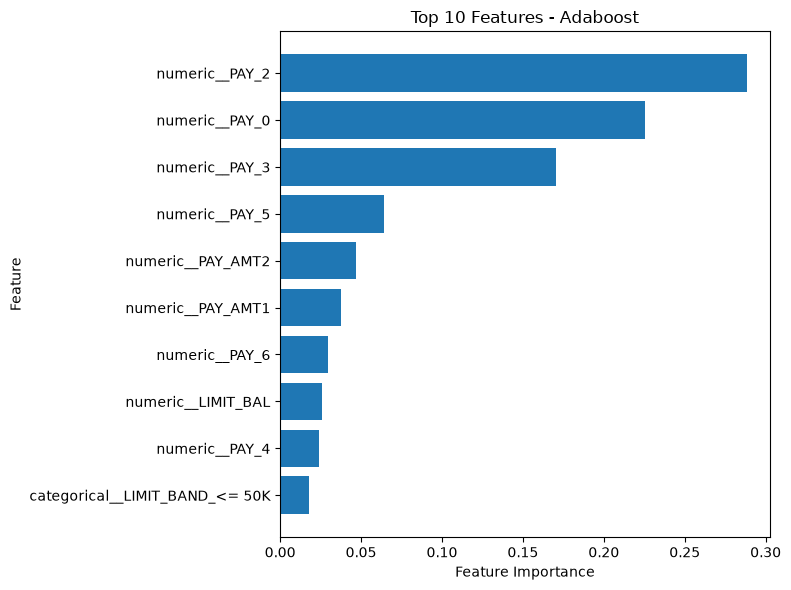

In [59]:
# Plot top 10 Random Forest feature importances

top_ada_features = ada_feature_importance.head(10)

plt.figure(figsize=(8, 6))

plt.barh(
    top_ada_features["Feature"][::-1],
    top_ada_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Adaboost")

plt.tight_layout()
plt.show()

In [60]:
# Feature importance for tuned Random Forest with demographics

rf_feature_names = (
    best_rf_demo
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

rf_importances = (
    best_rf_demo
    .named_steps["model"]
    .feature_importances_
)

rf_feature_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values(
    "Importance",
    ascending=False
)

rf_feature_importance.head(15)

,Feature,Importance
1,numeric__PAY_0,0.243821
2,numeric__PAY_2,0.093798
3,numeric__PAY_3,0.054235
4,numeric__PAY_4,0.045202
5,numeric__PAY_5,0.041233
13,numeric__PAY_AMT1,0.033014
20,numeric__UTIL_MAX,0.032697
19,numeric__UTIL_AVG,0.031866
22,numeric__UTIL_CHANGE,0.030365
14,numeric__PAY_AMT2,0.028928


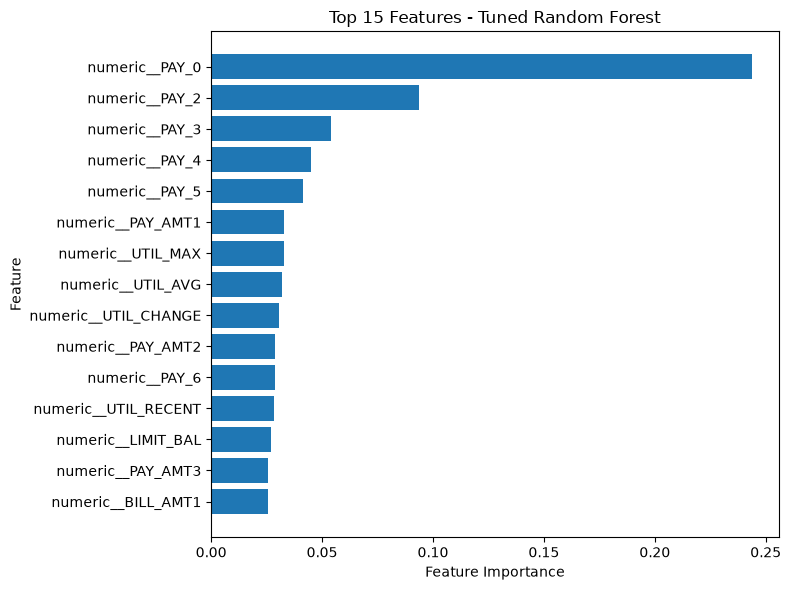

In [61]:
# Plot top 15 Random Forest feature importances

top_rf_features = rf_feature_importance.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top_rf_features["Feature"][::-1],
    top_rf_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Tuned Random Forest")

plt.tight_layout()
plt.show()

In [62]:
# LDA coefficients with demographics

da_feature_names = (
    best_da_demo
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

da_coefficients = (
    best_da_demo
    .named_steps["model"]
    .coef_[0]
)

da_coef_df = pd.DataFrame({
    "Feature": da_feature_names,
    "Coefficient": da_coefficients
})

da_coef_df["Absolute_Coefficient"] = (
    da_coef_df["Coefficient"].abs()
)

da_coef_df = da_coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

da_coef_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
28,categorical__EDUCATION_4,-1.133547,1.133547
19,numeric__UTIL_AVG,-0.855085,0.855085
35,categorical__LIMIT_BAND_> 500K,0.546320,0.546320
1,numeric__PAY_0,0.512225,0.512225
22,numeric__UTIL_CHANGE,-0.296653,0.296653
29,categorical__MARRIAGE_2,-0.206830,0.206830
34,categorical__LIMIT_BAND_<= 50K,0.192542,0.192542
20,numeric__UTIL_MAX,-0.184709,0.184709
32,categorical__LIMIT_BAND_300K-500K,0.182817,0.182817
27,categorical__EDUCATION_3,-0.156888,0.156888


In [63]:
# Logistic Regression coefficients with demographics

log_feature_names = (
    best_log_demo
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

log_coefficients = (
    best_log_demo
    .named_steps["model"]
    .coef_[0]
)

log_coef_df = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": log_coefficients
})

log_coef_df["Absolute_Coefficient"] = (
    log_coef_df["Coefficient"].abs()
)

log_coef_df = log_coef_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

log_coef_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
28,categorical__EDUCATION_4,-1.259233,1.259233
1,numeric__PAY_0,0.596711,0.596711
35,categorical__LIMIT_BAND_> 500K,0.537616,0.537616
19,numeric__UTIL_AVG,-0.490626,0.490626
23,numeric__HIGH_UTIL_MONTHS,0.350840,0.350840
14,numeric__PAY_AMT2,-0.236090,0.236090
0,numeric__LIMIT_BAL,-0.225629,0.225629
29,categorical__MARRIAGE_2,-0.203524,0.203524
32,categorical__LIMIT_BAND_300K-500K,0.186771,0.186771
34,categorical__LIMIT_BAND_<= 50K,0.170987,0.170987


In [64]:
# best tuned Decision Tree pipeline
dt_demo_tuned = dt_grid_demo.best_estimator_

dt_preprocessor = dt_demo_tuned.named_steps["preprocessor"]
dt_model = dt_demo_tuned.named_steps["model"]

feature_names = dt_preprocessor.get_feature_names_out()

importances = dt_model.feature_importances_

dt_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

dt_feature_importance = dt_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(dt_feature_importance.head(15))

,Feature,Importance
1,numeric__PAY_0,0.719421
2,numeric__PAY_2,0.136860
14,numeric__PAY_AMT2,0.039745
4,numeric__PAY_4,0.037392
20,numeric__UTIL_MAX,0.030728
3,numeric__PAY_3,0.015723
5,numeric__PAY_5,0.013229
24,numeric__AGE,0.006901
27,categorical__EDUCATION_3,0.000000
23,numeric__HIGH_UTIL_MONTHS,0.000000


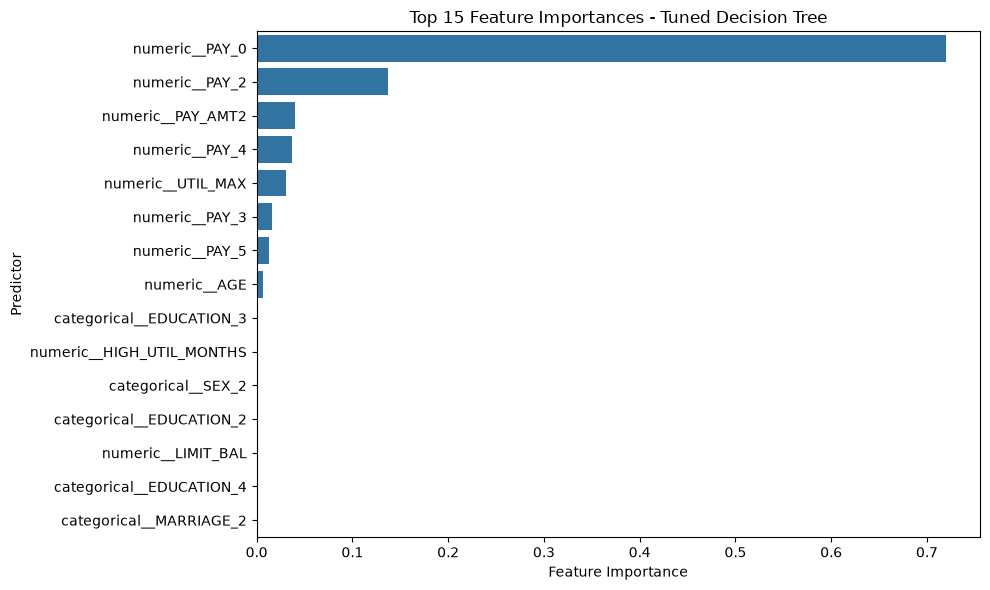

In [65]:
# best tuned decision tree feature importances
top_features_demo = dt_feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features_demo,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Tuned Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

In [66]:
# best tuned Decision Tree without demographics
dt_no_demo_tuned = dt_grid_no_demo.best_estimator_

dt_no_demo_preprocessor = dt_no_demo_tuned.named_steps["preprocessor"]
dt_no_demo_model = dt_no_demo_tuned.named_steps["model"]

dt_no_demo_feature_names = (
    dt_no_demo_preprocessor.get_feature_names_out()
)

dt_no_demo_importances = dt_no_demo_model.feature_importances_

dt_no_demo_feature_importance = pd.DataFrame({
    "Feature": dt_no_demo_feature_names,
    "Importance": dt_no_demo_importances
})

dt_no_demo_feature_importance = (
    dt_no_demo_feature_importance.sort_values(
        by="Importance",
        ascending=False
    )
)
display(dt_no_demo_feature_importance.head(15))

,Feature,Importance
1,numeric__PAY_0,0.724421
2,numeric__PAY_2,0.137811
14,numeric__PAY_AMT2,0.040022
4,numeric__PAY_4,0.037652
20,numeric__UTIL_MAX,0.030942
3,numeric__PAY_3,0.015832
5,numeric__PAY_5,0.013321
24,categorical__EDUCATION_2,0.000000
21,numeric__UTIL_RECENT,0.000000
22,numeric__UTIL_CHANGE,0.000000


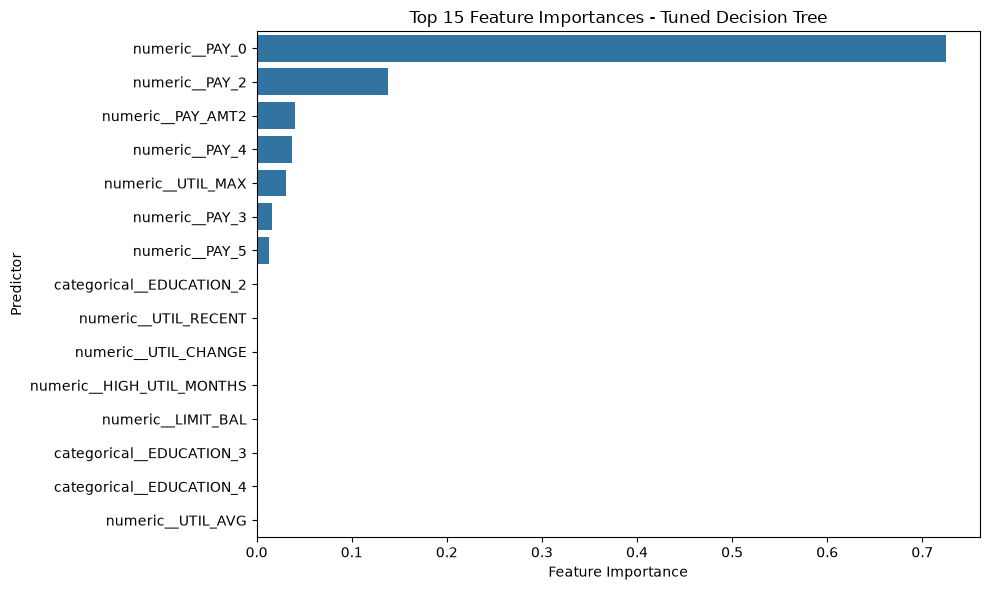

In [67]:
# best tuned decision tree feature importances no demographics
top_features_no_demo = dt_no_demo_feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features_no_demo,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Tuned Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

### Model Interpretation

The tuned Random Forest model identified repayment history as the most important
source of predictive information. `PAY_0`, representing the most recent repayment
status, had the largest feature importance by a substantial margin. Other recent
repayment-status variables, including `PAY_2` through `PAY_6`, were also among
the most influential predictors. Payment amounts, credit utilization measures,
and credit limit also contributed to the model.

The Logistic Regression coefficients similarly showed that recent repayment
status, particularly `PAY_0`, was strongly associated with predicted default.
Several credit-limit, payment, utilization, age, and education-related variables
also had relatively large coefficients. Positive coefficients indicate an
increase in the predicted log-odds of default, while negative coefficients
indicate a decrease, holding the other model variables constant.

`PAY_2`,`PAY_0`, and `PAY_3` were identified as the most important features for
Adaboost. The other repayment variables were also idenfied as significant.
`LIMIT_BAL` and `LIMIT_BAL_BAND` were in the top 10 important features but scored
less than 3%. 

For Linear Discriminant Analysis, demographic features were most relevant.
`EDUCATION_4` and other demographic features were present in the model, but 
`EDUCATION_4` had the highest absolute coeffient. However, the coefficent was
negative meaning theres an inverse relationship with education level and default.
Non demographic features utilzed pertained to the utilization and bill pay.

Overall, both modeling approaches indicate that repayment behavior provides
substantial information for identifying customers at higher risk of default.

# Model Selection

# Discussion